/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_45168/1007256455.py:105: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


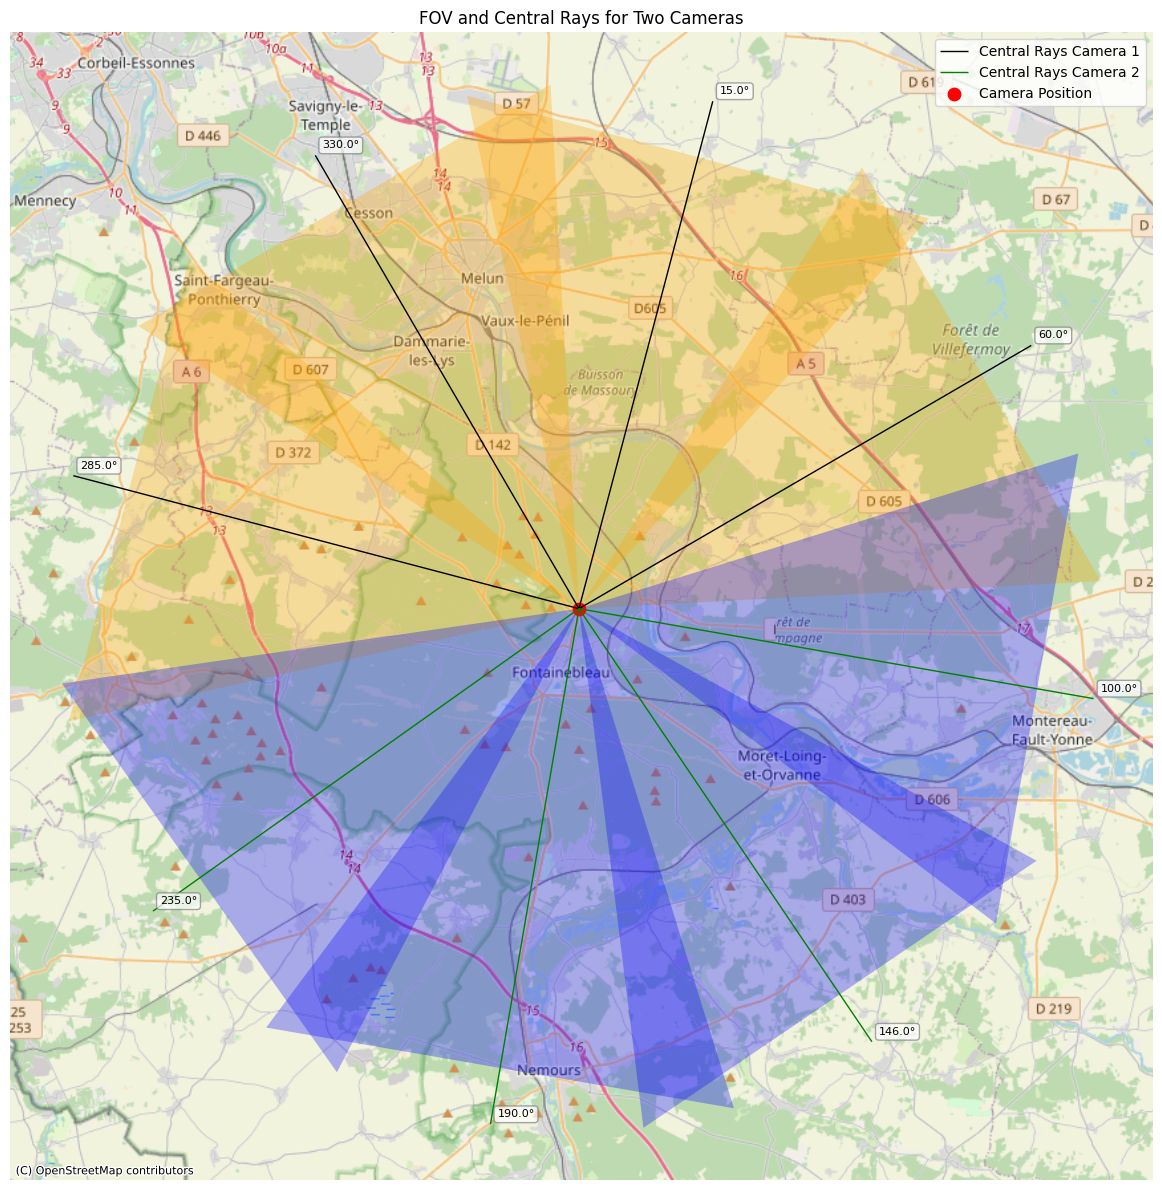

In [1]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import pandas as pd

# Function to build FOV geometries
def build_fov_geometries(cam_loc, azimuth_deg, fov_deg=54.2, view_distance=20000):
    cam_x, cam_y, cam_z, _ = cam_loc
    cam_point = Point(cam_x, cam_y)

    # FOV cone
    half_fov = fov_deg / 2
    angles_deg = [azimuth_deg - half_fov, azimuth_deg + half_fov]
    angles_rad = np.radians(angles_deg)

    cone_pts = [
        cam_point,
        Point(cam_x + view_distance * np.sin(angles_rad[0]),
              cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]),
              cam_y + view_distance * np.cos(angles_rad[1]))
    ]
    gdf_fov = gpd.GeoSeries([g.convex_hull for g in [cone_pts[0].buffer(1).union(cone_pts[1]).union(cone_pts[2])]], crs="EPSG:2154")

    # Central ray
    azimuth_rad = np.radians(azimuth_deg)
    target_x = cam_x + view_distance * np.sin(azimuth_rad)
    target_y = cam_y + view_distance * np.cos(azimuth_rad)
    ray = LineString([(cam_x, cam_y), (target_x, target_y)])
    gdf_ray = gpd.GeoSeries([ray], crs="EPSG:2154")

    return gdf_fov, gdf_ray

# Camera location
camera_loc = (2.7109, 48.4267, 0, "EPSG:4326")  # Longitude, Latitude, Altitude, CRS

# Convert camera location to EPSG:2154
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
cam_x, cam_y = transformer.transform(camera_loc[0], camera_loc[1])
cam_loc = (cam_x, cam_y, 0, "EPSG:2154")

# Azimuths for both cameras
azimuths_cam1 = [285, 330, 15, 60]
azimuths_cam2 = [100, 146, 190, 235]

# Build geometries for both cameras
fov_all_cam1 = []
ray_all_cam1 = []
fov_all_cam2 = []
ray_all_cam2 = []

# Process azimuths for Camera 1
for az in azimuths_cam1:
    gdf_fov, gdf_ray = build_fov_geometries(cam_loc, azimuth_deg=az)
    fov_all_cam1.append(gdf_fov)
    ray_all_cam1.append(gdf_ray)

# Process azimuths for Camera 2
for az in azimuths_cam2:
    gdf_fov, gdf_ray = build_fov_geometries(cam_loc, azimuth_deg=az)
    fov_all_cam2.append(gdf_fov)
    ray_all_cam2.append(gdf_ray)

# Combine all geometries into GeoDataFrames
gdf_all_fov_cam1 = gpd.GeoSeries(pd.concat(fov_all_cam1, ignore_index=True)).set_crs("EPSG:2154")
gdf_all_ray_cam1 = gpd.GeoSeries(pd.concat(ray_all_cam1, ignore_index=True)).set_crs("EPSG:2154")
gdf_all_fov_cam2 = gpd.GeoSeries(pd.concat(fov_all_cam2, ignore_index=True)).set_crs("EPSG:2154")
gdf_all_ray_cam2 = gpd.GeoSeries(pd.concat(ray_all_cam2, ignore_index=True)).set_crs("EPSG:2154")
gdf_cam = gpd.GeoSeries([Point(cam_x, cam_y)], crs="EPSG:2154")

# Reproject to Web Mercator
gdf_all_fov_cam1_web = gdf_all_fov_cam1.to_crs(epsg=3857)
gdf_all_ray_cam1_web = gdf_all_ray_cam1.to_crs(epsg=3857)
gdf_all_fov_cam2_web = gdf_all_fov_cam2.to_crs(epsg=3857)
gdf_all_ray_cam2_web = gdf_all_ray_cam2.to_crs(epsg=3857)
gdf_cam_web = gdf_cam.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
gdf_all_fov_cam1_web.plot(ax=ax, color='orange', alpha=0.3, label="FOV Camera 1")
gdf_all_ray_cam1_web.plot(ax=ax, color='black', linewidth=1, label="Central Rays Camera 1")
gdf_all_fov_cam2_web.plot(ax=ax, color='blue', alpha=0.3, label="FOV Camera 2")
gdf_all_ray_cam2_web.plot(ax=ax, color='green', linewidth=1, label="Central Rays Camera 2")
gdf_cam_web.plot(ax=ax, color='red', markersize=80, label="Camera Position")

# Add azimuth labels
for ray_geom, azimuth in zip(gdf_all_ray_cam1_web.geometry, azimuths_cam1):
    x_end, y_end = ray_geom.coords[-1]
    ax.annotate(f"{azimuth:.1f}°", (x_end, y_end), xytext=(5, 5),
                textcoords="offset points", fontsize=8, color="black",
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'))

for ray_geom, azimuth in zip(gdf_all_ray_cam2_web.geometry, azimuths_cam2):
    x_end, y_end = ray_geom.coords[-1]
    ax.annotate(f"{azimuth:.1f}°", (x_end, y_end), xytext=(5, 5),
                textcoords="offset points", fontsize=8, color="black",
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'))

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("FOV and Central Rays for Two Cameras")
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()
